In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))

Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\clustering
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Preprocessing (Encoding & Scaling)
df = pd.read_csv('data/train.csv')
df_proc = df.drop(columns=['Employee_Id'])
le = LabelEncoder()
df_proc['Work_Life_Balance'] = le.fit_transform(df_proc['Work_Life_Balance'])
df_proc['Lives_With_Family'] = le.fit_transform(df_proc['Lives_With_Family'])
df_proc = pd.get_dummies(df_proc, columns=['Work_From', 'Working_State'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_proc.drop(columns=['Stress_Level']))

# 2. DBSCAN Model
# eps: The distance within which to search for neighboring points
# min_samples: The minimum number of points to form a dense region
dbscan = DBSCAN(eps=3.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# 3. Evaluation: Silhouette Score
# We calculate the score for the points that were not labeled as noise (-1)
mask = db_labels != -1
score = silhouette_score(X_scaled[mask], db_labels[mask])
print(f"DBSCAN Silhouette Score: {score:.4f}")

DBSCAN Silhouette Score: 0.1935


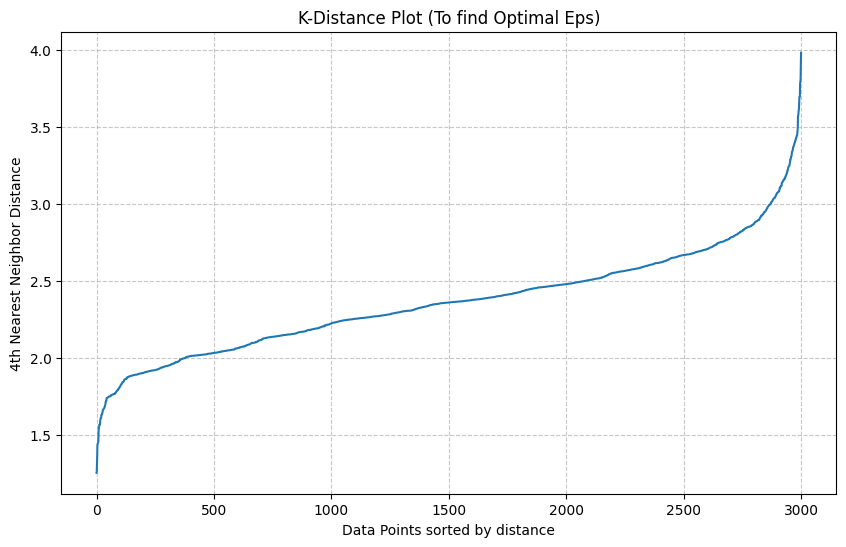

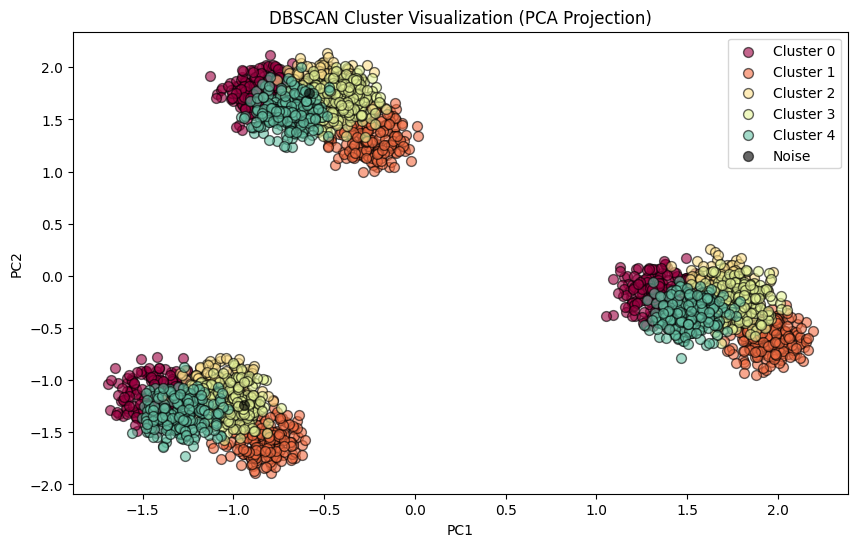

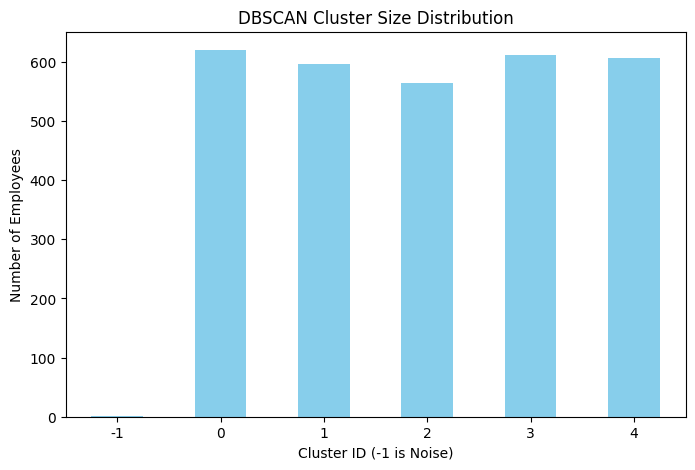

In [7]:

df_proc = df.drop(columns=['Employee_Id'])
le = LabelEncoder()
df_proc['Work_Life_Balance'] = le.fit_transform(df_proc['Work_Life_Balance'])
df_proc['Lives_With_Family'] = le.fit_transform(df_proc['Lives_With_Family'])
df_proc = pd.get_dummies(df_proc, columns=['Work_From', 'Working_State'])

X_scaled = StandardScaler().fit_transform(df_proc.drop(columns=['Stress_Level']))

# 1. K-Distance Plot (To determine optimal eps)
# For DBSCAN, we look for the 'elbow' in the k-distance graph.
# k is typically min_samples - 1. Let's use min_samples=5, so k=4.
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Plot (To find Optimal Eps)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('4th Nearest Neighbor Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('dbscan_k_distance.png')
plt.show()

# 2. DBSCAN Clustering
# Based on the previous runs and the elbow, eps=3.5 seems reasonable.
dbscan = DBSCAN(eps=3.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 3. PCA Cluster Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Black for noise
    class_member_mask = (labels == k)
    xy = X_pca[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], color=tuple(col), edgecolor='k', s=50, 
                label=f'Cluster {k}' if k != -1 else 'Noise', alpha=0.6)

plt.title('DBSCAN Cluster Visualization (PCA Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.savefig('dbscan_pca_viz.png')
plt.show()

# 4. Cluster Distribution Bar Chart
label_series = pd.Series(labels).value_counts().sort_index()
plt.figure(figsize=(8, 5))
label_series.plot(kind='bar', color='skyblue')
plt.title('DBSCAN Cluster Size Distribution')
plt.xlabel('Cluster ID (-1 is Noise)')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.savefig('dbscan_distribution.png')
plt.show()
